In [311]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pickle
import pathlib

sns.set_style("whitegrid")
sns.set_context("paper")
sns.set_palette("deep", color_codes=True)


In [312]:
results_folder = "qaoa_results_8_cold_start"
result_files = {path.as_posix().split("/")[-1].split(".")[0]: {"path": path} for path in list(pathlib.Path(f"qaoa/{results_folder}").glob("*.npz"))}
result_files

{'5PTI_22_28_4_8_layers': {'path': PosixPath('qaoa/qaoa_results_8_cold_start/5PTI_22_28_4_8_layers.npz')},
 '5PTI_22_28_4_12_layers': {'path': PosixPath('qaoa/qaoa_results_8_cold_start/5PTI_22_28_4_12_layers.npz')},
 '5PTI_18_22_5_4_layers': {'path': PosixPath('qaoa/qaoa_results_8_cold_start/5PTI_18_22_5_4_layers.npz')},
 '5PTI_18_22_4_12_layers': {'path': PosixPath('qaoa/qaoa_results_8_cold_start/5PTI_18_22_4_12_layers.npz')},
 '5PTI_18_22_4_1_layers': {'path': PosixPath('qaoa/qaoa_results_8_cold_start/5PTI_18_22_4_1_layers.npz')},
 '5PTI_18_22_4_4_layers': {'path': PosixPath('qaoa/qaoa_results_8_cold_start/5PTI_18_22_4_4_layers.npz')},
 '5PTI_22_28_4_2_layers': {'path': PosixPath('qaoa/qaoa_results_8_cold_start/5PTI_22_28_4_2_layers.npz')},
 '5PTI_18_22_5_1_layers': {'path': PosixPath('qaoa/qaoa_results_8_cold_start/5PTI_18_22_5_1_layers.npz')},
 '5PTI_22_28_4_1_layers': {'path': PosixPath('qaoa/qaoa_results_8_cold_start/5PTI_22_28_4_1_layers.npz')},
 '5PTI_18_22_5_2_layers': {'path'

In [313]:
data_keys = ["cost_history", "target_probs", "target_indices", "best_target_index", "conformation_map"]

for name, data in result_files.items():
    with open(data["path"], 'rb') as f:
        saved_results = np.load(f, allow_pickle=True)
        result_files[name]["data"] = {key: saved_results[key] for key in data_keys}

    result_files[name]["protein"] = name.split("_")[0]
    result_files[name]["start_residue"] = int(name.split("_")[1])
    result_files[name]["end_residue"] = int(name.split("_")[2])
    result_files[name]["rotamer_count"] = int(name.split("_")[3])
    result_files[name]["qaoa_layers"] = int(name.split("_")[4])

    result_files[name]["subsection"] = f"{result_files[name]['start_residue']}-{result_files[name]['end_residue']}"
    result_files[name]["subsection_length"] = result_files[name]["end_residue"] - result_files[name]["start_residue"] + 1

In [314]:
result_files.keys()

dict_keys(['5PTI_22_28_4_8_layers', '5PTI_22_28_4_12_layers', '5PTI_18_22_5_4_layers', '5PTI_18_22_4_12_layers', '5PTI_18_22_4_1_layers', '5PTI_18_22_4_4_layers', '5PTI_22_28_4_2_layers', '5PTI_18_22_5_1_layers', '5PTI_22_28_4_1_layers', '5PTI_18_22_5_2_layers', '5PTI_22_28_4_4_layers', '5PTI_18_22_4_2_layers', '5PTI_18_22_4_8_layers', '5PTI_18_22_5_8_layers'])

In [321]:
result_files["5PTI_18_22_5_8_layers"]["data"]['target_indices']

array([2704, 2696, 1680, 1672], dtype=int32)

In [316]:
target_probs_records = []

for name, data in result_files.items():
    target_probs = result_files[name]["data"]['target_probs']
    print("Shape of target_probs:", target_probs.shape)  # Should be (30, 16)

    # Sum across the 16 conformations for each seed
    summed_probs = target_probs.sum(axis=1)  # Shape becomes (30,)
    print("Shape after summing across conformations:", summed_probs.shape)

    # Create a record for each seed with its summed probability
    for seed_idx, summed_prob in enumerate(summed_probs):
        record = {
            'protein': result_files[name]['protein'],
            'subsection': result_files[name]['subsection'],
            'subsection_length': result_files[name]['subsection_length'],
            'rotamer_count': result_files[name]['rotamer_count'],
            'qaoa_layers': result_files[name]['qaoa_layers'],
            'seed': seed_idx,
            'target_prob': summed_prob  # This is now the sum across all 16 conformations
        }
        target_probs_records.append(record)

# Create dataframe from records
target_probs_df = pd.DataFrame(target_probs_records)
target_probs_df.head()
target_probs_df


Shape of target_probs: (30, 16)
Shape after summing across conformations: (30,)
Shape of target_probs: (30, 16)
Shape after summing across conformations: (30,)
Shape of target_probs: (30, 4)
Shape after summing across conformations: (30,)
Shape of target_probs: (30, 4)
Shape after summing across conformations: (30,)
Shape of target_probs: (30, 4)
Shape after summing across conformations: (30,)
Shape of target_probs: (30, 4)
Shape after summing across conformations: (30,)
Shape of target_probs: (30, 16)
Shape after summing across conformations: (30,)
Shape of target_probs: (30, 4)
Shape after summing across conformations: (30,)
Shape of target_probs: (30, 16)
Shape after summing across conformations: (30,)
Shape of target_probs: (30, 4)
Shape after summing across conformations: (30,)
Shape of target_probs: (30, 16)
Shape after summing across conformations: (30,)
Shape of target_probs: (30, 4)
Shape after summing across conformations: (30,)
Shape of target_probs: (30, 4)
Shape after summ

,protein,subsection,subsection_length,rotamer_count,qaoa_layers,seed,target_prob
0,5PTI,22-28,7,4,8,0,0.951118
1,5PTI,22-28,7,4,8,1,0.971245
2,5PTI,22-28,7,4,8,2,0.994446
3,5PTI,22-28,7,4,8,3,0.971294
4,5PTI,22-28,7,4,8,4,0.994334
...,...,...,...,...,...,...,...
415,5PTI,18-22,5,5,8,25,0.009691
416,5PTI,18-22,5,5,8,26,0.065068
417,5PTI,18-22,5,5,8,27,0.051652
418,5PTI,18-22,5,5,8,28,0.009345


In [317]:
target_probs_df

,protein,subsection,subsection_length,rotamer_count,qaoa_layers,seed,target_prob
0,5PTI,22-28,7,4,8,0,0.951118
1,5PTI,22-28,7,4,8,1,0.971245
2,5PTI,22-28,7,4,8,2,0.994446
3,5PTI,22-28,7,4,8,3,0.971294
4,5PTI,22-28,7,4,8,4,0.994334
...,...,...,...,...,...,...,...
415,5PTI,18-22,5,5,8,25,0.009691
416,5PTI,18-22,5,5,8,26,0.065068
417,5PTI,18-22,5,5,8,27,0.051652
418,5PTI,18-22,5,5,8,28,0.009345


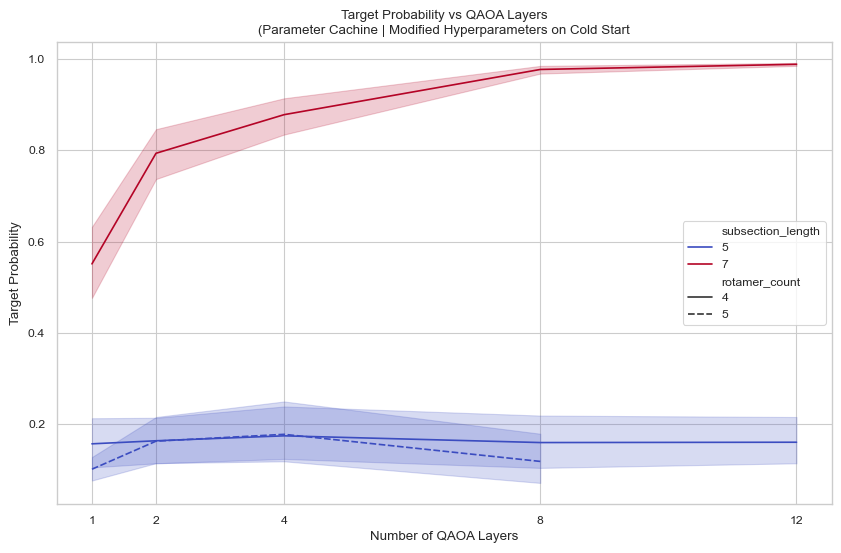

In [318]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(data=target_probs_df,
             x="qaoa_layers", y="target_prob",
             hue='subsection_length', style='rotamer_count',
             markers=False,
             palette=sns.color_palette('coolwarm', as_cmap = True),
             ax=ax)

ax.set_xticks([1, 2, 4, 8, 12])

ax.set_title("Target Probability vs QAOA Layers\n(Parameter Cachine | Modified Hyperparameters on Cold Start")
ax.set_xlabel("Number of QAOA Layers")
ax.set_ylabel("Target Probability")

plt.savefig(f"plots/{results_folder}_2.svg", dpi=300, bbox_inches='tight')

In [319]:
# import numpy as np
# import pathlib
#
# results_folder = "qaoa_results_6"
# result_files = list(pathlib.Path(f"qaoa/{results_folder}").glob("*.npz"))
#
# print(f"Verifying {len(result_files)} result files...\n")
#
# for result_file in result_files[:3]:  # Check first 3 files
#     print(f"Checking: {result_file.name}")
#
#     with open(result_file, 'rb') as f:
#         saved_results = np.load(f, allow_pickle=True)
#         target_probs = saved_results['target_probs']
#         conformation_map = saved_results['conformation_map']
#
#     print(f"  target_probs shape: {target_probs.shape}")
#     print(f"  conformation_map shape: {conformation_map.shape}")
#
#     # Sum across seeds (axis 0 for target_probs, axis 1 for conformation_map)
#     target_probs_summed = target_probs.sum(axis=0)
#
#     # conformation_map seems to be object array, so we need to extract probabilities
#     conf_probs_summed = np.array([conf['probabilities'] for conf in conformation_map]).sum(axis=1)
#
#     # Compare
#     difference = np.abs(target_probs_summed - conf_probs_summed)
#     max_diff = np.max(difference)
#     mean_diff = np.mean(difference)
#
#     print(f"  Max difference: {max_diff:.2e}")
#     print(f"  Mean difference: {mean_diff:.2e}")
#
#     if max_diff < 1e-6:
#         print("  ✓ PASS: Probabilities match!\n")
#     else:
#         print(f"  ✗ FAIL: Probabilities don't match!")
#         print(f"    target_probs_summed: {target_probs_summed}")
#         print(f"    conf_probs_summed: {conf_probs_summed}\n")
